In [135]:
import pickle

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, learning_curve

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.decomposition import PCA

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score

## Exploratory Data Analysis

In [2]:
df = pd.read_csv('dataset_8k.csv')

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.rename(columns={
    'N': 'nitrogen',
    'P': 'phosphorus',
    'K': 'potassium',
    }, inplace=True)

df.head()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


- Nitrogen: mg/kg
- Potassium: mg/kg
- Phosporus: mg/kg
- Temperature: Celcius
- Humidity
- pH
- Rainfall: per month in mm

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nitrogen     8800 non-null   int64  
 1   phosphorus   8800 non-null   int64  
 2   potassium    8800 non-null   int64  
 3   temperature  8800 non-null   float64
 4   humidity     8800 non-null   float64
 5   ph           8800 non-null   float64
 6   rainfall     8800 non-null   float64
 7   label        8800 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 550.1+ KB


In [5]:
df.describe(include="all")

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
count,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rice
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400
mean,55.080909,51.444091,40.482727,26.774572,71.443720,6.609499,100.669506,NaN
std,37.059675,27.973451,38.555468,5.322922,22.761454,0.877838,56.017885,NaN
min,0.000000,4.000000,5.000000,8.825675,14.258040,3.504752,20.211267,NaN
25%,25.000000,30.000000,20.000000,23.826868,58.192235,6.081469,60.745835,NaN
50%,42.000000,51.000000,29.000000,26.924435,79.960550,6.566980,90.402966,NaN
75%,89.000000,66.000000,46.000000,29.774256,89.417267,7.086870,122.704272,NaN


In [6]:
missing_rate = df.isna().mean().sort_values(ascending=False).round(4)

print(missing_rate)

nitrogen       0.0
phosphorus     0.0
potassium      0.0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label          0.0
dtype: float64


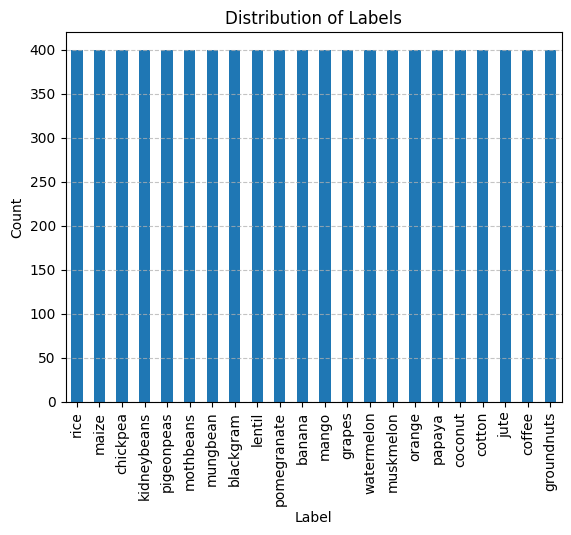

In [124]:
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.grid(axis='y', alpha=0.75, linestyle="--")
plt.show()

In [8]:
dup_rate = df.duplicated().mean()
df.drop_duplicates()

print(dup_rate)

0.0


In [9]:
total_labels = df["label"].nunique()
print(f"Total unique labels: {total_labels}")

Total unique labels: 22


## Feature Engineering

In [12]:
# known ratios in agriculture
df['n_p_ratio'] = df['nitrogen'] / (df['phosphorus'] + 1e-6)
df['n_k_ratio'] = df['nitrogen'] / (df['potassium'] + 1e-6)
df['p_k_ratio'] = df['phosphorus'] / (df['potassium'] + 1e-6)

# total nutrient load
df['npk_total'] = df['nitrogen'] + df['phosphorus'] + df['potassium']

# ratio to check whether a humidity level is caused by rainfall
df["humidity_rain_ratio"] = df["humidity"] / (df["rainfall"] + 1e-6)

# ph categorization
df['ph_type'] = pd.cut(
    df['ph'],
    bins=[0, 6.0, 7.5, 14],
    labels=['acidic', 'neutral', 'alkaline']
)

# temperature categorization
df['temp_zone'] = pd.cut(
    df['temperature'],
    bins=[0, 15, 25, 50],
    labels=['cool', 'moderate', 'hot']
)

df.head()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,n_p_ratio,n_k_ratio,p_k_ratio,humidity_rain_ratio,ph_type,npk_total,temp_zone
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2.142857,2.093023,0.976744,0.404083,neutral,175,moderate
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1.465517,2.073171,1.414634,0.354369,neutral,184,moderate
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1.090909,1.363636,1.250000,0.311863,alkaline,159,moderate
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,2.114286,1.850000,0.875000,0.330054,neutral,149,hot
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1.857143,1.857143,1.000000,0.310619,alkaline,162,moderate


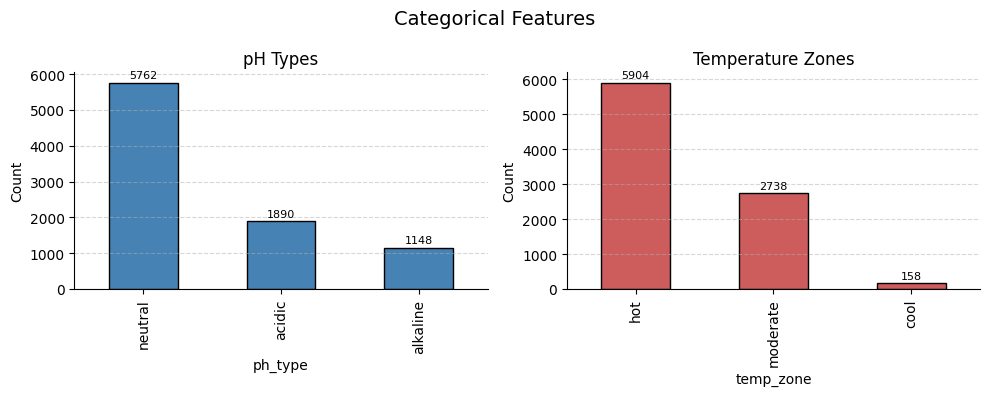

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# PH Plot
df["ph_type"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("pH Types", fontsize=12)
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Temp Plot
df["temp_zone"].value_counts().plot(
    kind="bar", ax=axes[1], color="indianred", edgecolor="black"
)
axes[1].set_title("Temperature Zones", fontsize=12)
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Final figure adjustments
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=8)

fig.suptitle("Categorical Features", fontsize=14)
plt.tight_layout()
plt.show()

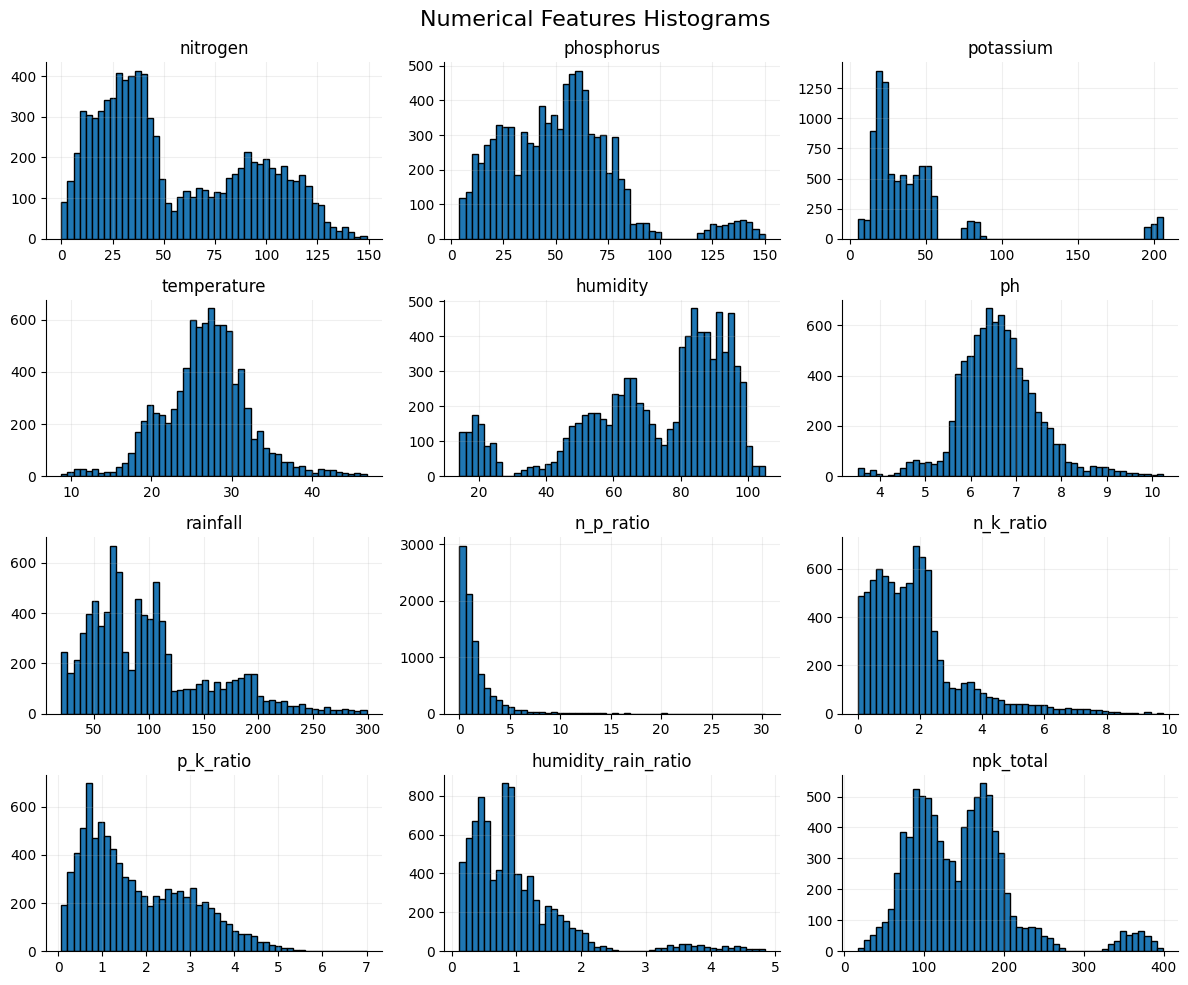

In [42]:
df.hist(
    bins=50,
    figsize=(12, 10),
    edgecolor="black"
)

plt.suptitle("Numerical Features Histograms", fontsize=16)

# Clean up all axes
for ax in plt.gcf().axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

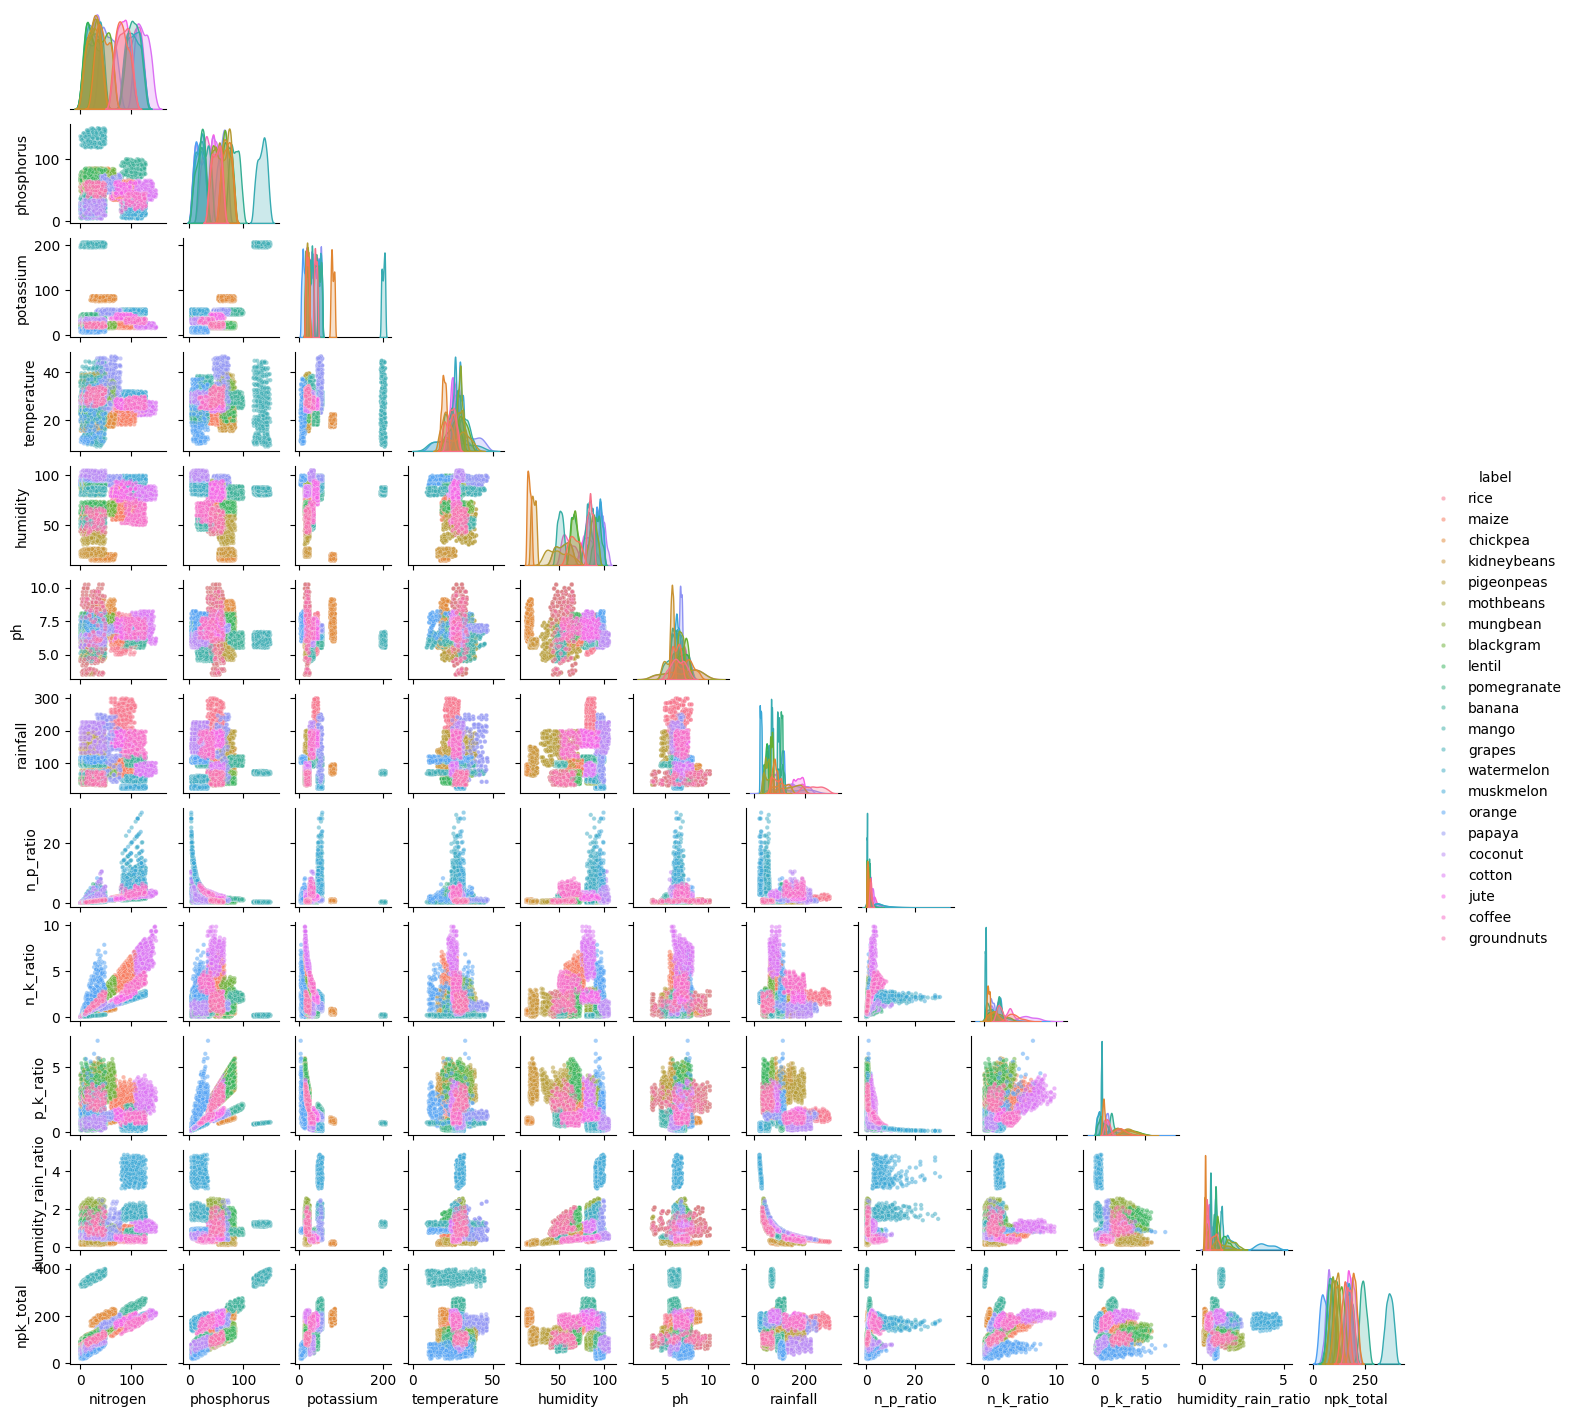

In [14]:
sns.pairplot(
    df,
    hue="label",
    corner=True,
    height=1.2,
    plot_kws={'s': 10, 'alpha': 0.5},   # smaller points
)

In [38]:
df.columns

Index(['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph',
       'rainfall', 'label', 'n_p_ratio', 'n_k_ratio', 'p_k_ratio',
       'humidity_rain_ratio', 'ph_type', 'npk_total', 'temp_zone'],
      dtype='object')

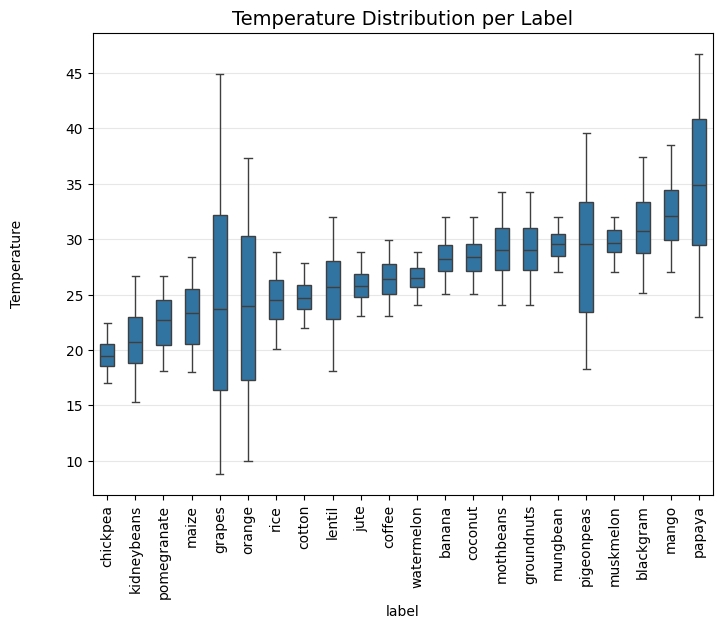

In [73]:
# order labels by median temperature
order = df.groupby("label")["temperature"].median().sort_values().index

plt.figure(figsize=(8, 6))
sns.boxplot(
    x="label",
    y="temperature",
    data=df,
    order=order,
    width=0.5
)

plt.title("Temperature Distribution per Label", fontsize=14)
plt.xticks(rotation=90)
plt.ylabel("Temperature", rotation=90, labelpad=30)
plt.grid(True, axis="y", alpha=0.3)

plt.show()

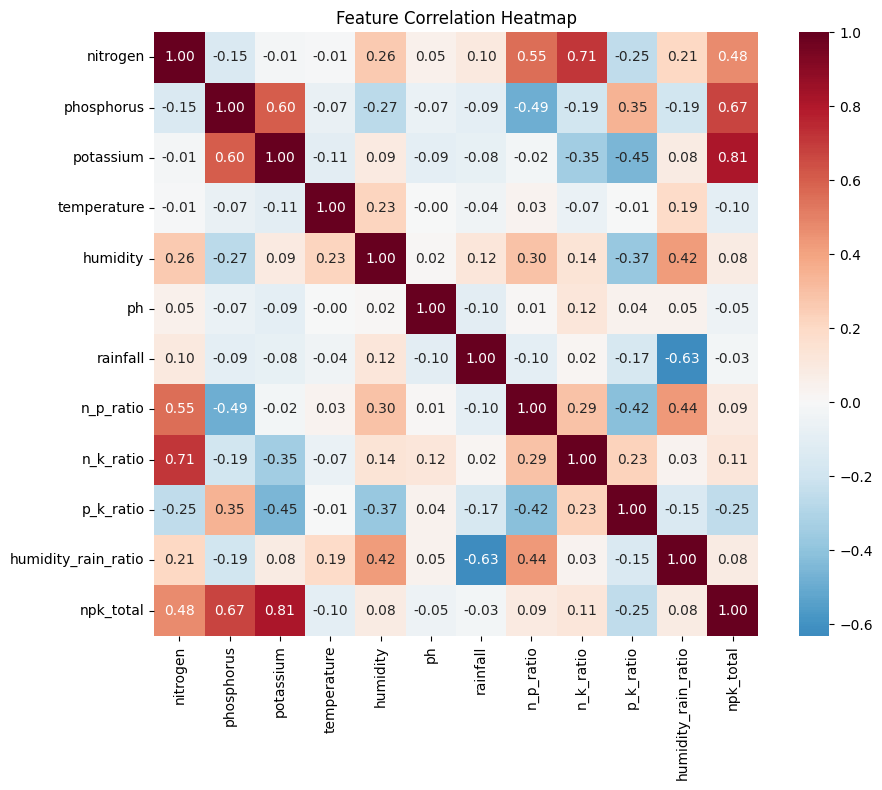

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   nitrogen             8800 non-null   int64   
 1   phosphorus           8800 non-null   int64   
 2   potassium            8800 non-null   int64   
 3   temperature          8800 non-null   float64 
 4   humidity             8800 non-null   float64 
 5   ph                   8800 non-null   float64 
 6   rainfall             8800 non-null   float64 
 7   label                8800 non-null   object  
 8   n_p_ratio            8800 non-null   float64 
 9   n_k_ratio            8800 non-null   float64 
 10  p_k_ratio            8800 non-null   float64 
 11  humidity_rain_ratio  8800 non-null   float64 
 12  ph_type              8800 non-null   category
 13  npk_total            8800 non-null   int64   
 14  temp_zone            8800 non-null   category
dtypes: category(2), float

In [71]:
le = LabelEncoder()
df["le_label"] = le.fit_transform(df["label"])

In [79]:
num_features = ["nitrogen", "phosphorus", "potassium", "temperature", "humidity", "ph", "rainfall", "n_p_ratio", "n_k_ratio", "p_k_ratio", "npk_total", "humidity_rain_ratio"]
cat_features = ["ph_type", "temp_zone"]

default_preprocessor = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

num_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

In [76]:
X = df.drop(["label", "le_label"], axis=1)
y = df["le_label"]

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [82]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Baseline Model

In [112]:
def cv_fit_no_search(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        m = clone(model)
        m.fit(X_train_fold, y_train_fold)

        preds = m.predict(X_val_fold)
        scores.append(accuracy_score(y_val_fold, preds))

    final_model = clone(model)
    final_model.fit(X, y)

    return final_model, np.mean(scores)

In [83]:
def show_learning_curve(model, name, X, y, cv):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # training curve
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label=f'Training score: {train_mean[-1]:.4f}')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')

    # validation curve
    plt.plot(train_sizes, test_mean, 'o-', color='green', label=f'Validation score: {test_mean[-1]:.4f}')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')

    plt.title(f'Learning Curve ({name})')
    plt.xlabel('Training Samples')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.show()

In [84]:
def show_confusion_matrix(y_true, y_pred, display_labels):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=True)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Best CV Accuracy: 0.9155


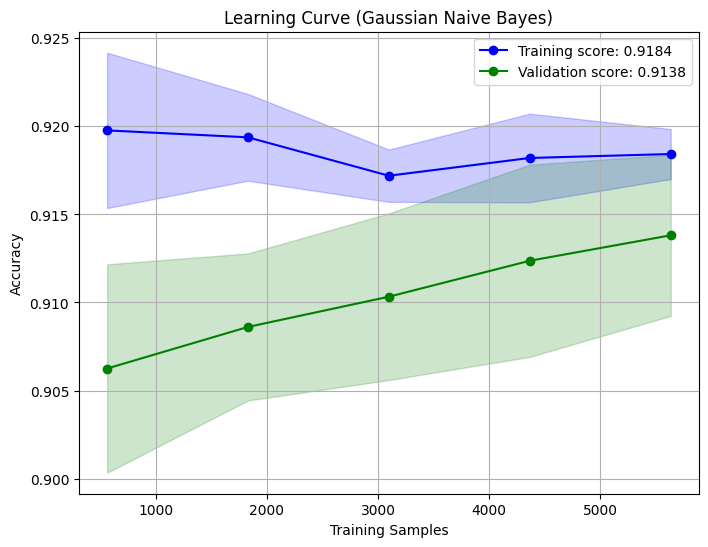

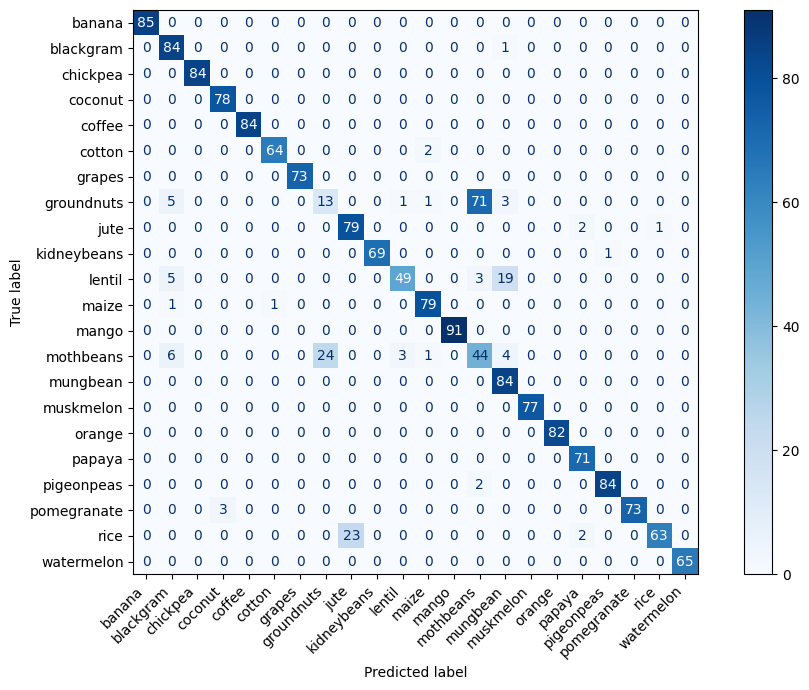

F1 Score: 0.8953
Recall: 0.9025
Precision: 0.9011


In [136]:
gnb = Pipeline([
    ('preprocessor', default_preprocessor),
    ('classifier', GaussianNB())
])

gnb_model, gnb_score = cv_fit_no_search(gnb, X_train, y_train)
print(f"Best CV Accuracy: {gnb_score:.4f}")

show_learning_curve(gnb, "Gaussian Naive Bayes", X_train, y_train, cv)

gnb_pred = gnb_model.predict(X_test)
show_confusion_matrix(y_test, gnb_pred, display_labels=le.classes_)

gnb_f1 = f1_score(y_test, gnb_pred, average="macro")
gnb_recall = recall_score(y_test, gnb_pred, average="macro")
gnb_precision = precision_score(y_test, gnb_pred, average="macro")

print(f"F1 Score: {gnb_f1:.4f}")
print(f"Recall: {gnb_recall:.4f}")
print(f"Precision: {gnb_precision:.4f}")

Best CV Accuracy: 0.9401


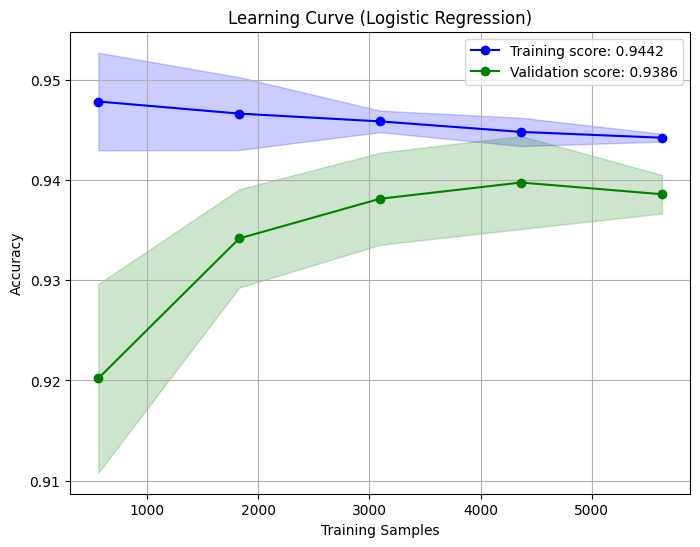

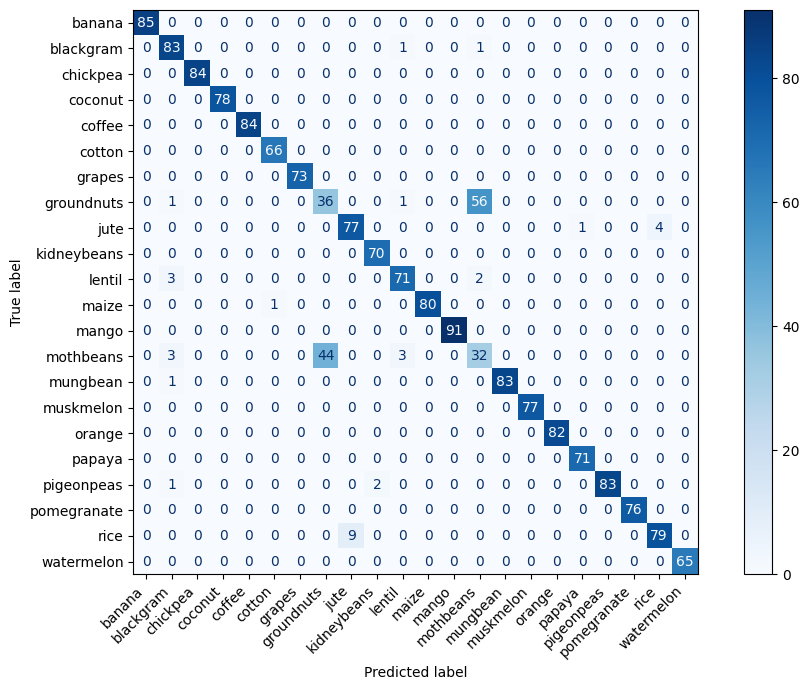

F1 Score: 0.9290
Recall: 0.9301
Precision: 0.9286


In [137]:
logreg = Pipeline([
    ('preprocessor', num_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_model, logreg_score = cv_fit_no_search(logreg, X_train, y_train)
print(f"Best CV Accuracy: {logreg_score:.4f}")

show_learning_curve(logreg, "Logistic Regression", X_train, y_train, cv)

logreg_pred = logreg_model.predict(X_test)
show_confusion_matrix(y_test, logreg_pred, display_labels=le.classes_)

logreg_f1 = f1_score(y_test, logreg_pred, average="macro")
logreg_recall = recall_score(y_test, logreg_pred, average="macro")
logreg_precision = precision_score(y_test, logreg_pred, average="macro")

print(f"F1 Score: {logreg_f1:.4f}")
print(f"Recall: {logreg_recall:.4f}")
print(f"Precision: {logreg_precision:.4f}")

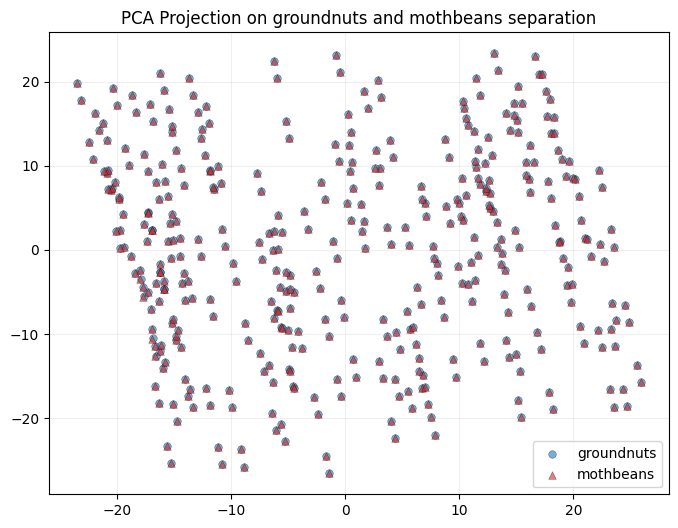

In [119]:
mask = df['label'].isin(['groundnuts', 'mothbeans'])
df_pair = df[mask].copy()
class0 = df_pair[df_pair['label'] == 'groundnuts']
class1 = df_pair[df_pair['label'] == 'mothbeans']

features = ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall']

X_pair = df_pair[features].values
y_pair = df_pair['label'].values

X_pca = PCA(n_components=2).fit_transform(X_pair)

# boolean masks (cleaner than string indexing repeatedly)
mask_g = (y_pair == 'groundnuts')
mask_m = (y_pair == 'mothbeans')

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[mask_g, 0], X_pca[mask_g, 1],
    label='groundnuts',
    c='#1f77b4',  # strong blue
    marker='o',
    s=30,
    alpha=0.6,
    edgecolors='black',
    linewidths=0.3
)

plt.scatter(
    X_pca[mask_m, 0], X_pca[mask_m, 1],
    label='mothbeans',
    c='#d62728',  # strong red
    marker='^',
    s=30,
    alpha=0.6,
    edgecolors='black',
    linewidths=0.3
)

plt.title("PCA Projection on groundnuts and mothbeans separation")
plt.legend()
plt.grid(alpha=0.2)
plt.savefig("hardest_separation.png")
plt.show()

## Main Model

In [91]:
def feature_importance(model, X, y):
    model.fit(X, y)
    # get feature importances
    importances = model.feature_importances_
    feature_names = X.columns

    # sort importances descending
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    sorted_features = [feature_names[i] for i in indices]

    plt.figure(figsize=(10, 6))
    plt.barh(sorted_features, sorted_importances, color="green")
    plt.xlabel("Feature Importance")
    plt.title("Feature Importance from Classifier")
    plt.gca().invert_yaxis()  # highest importance on top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

In [94]:
numeric_pipeline = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

poly_preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

logreg_v2 = Pipeline([
    ("preprocessor", poly_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, solver="saga"))
])

logreg_param_grid = {
    'preprocessor__num__poly__degree': [1, 2],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

logreg_search = GridSearchCV(
    estimator=logreg_v2,
    param_grid=logreg_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

logreg_search.fit(X_train, y_train)

print("Best Hyperparameters:", logreg_search.best_params_)
print("Best CV Accuracy:", logreg_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Hyperparameters: {'classifier__C': 100, 'classifier__penalty': 'l1', 'preprocessor__num__poly__degree': 1}
Best CV Accuracy: 0.9440340909090909


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


F1 Score: 0.9340
Recall: 0.9344
Precision: 0.9338


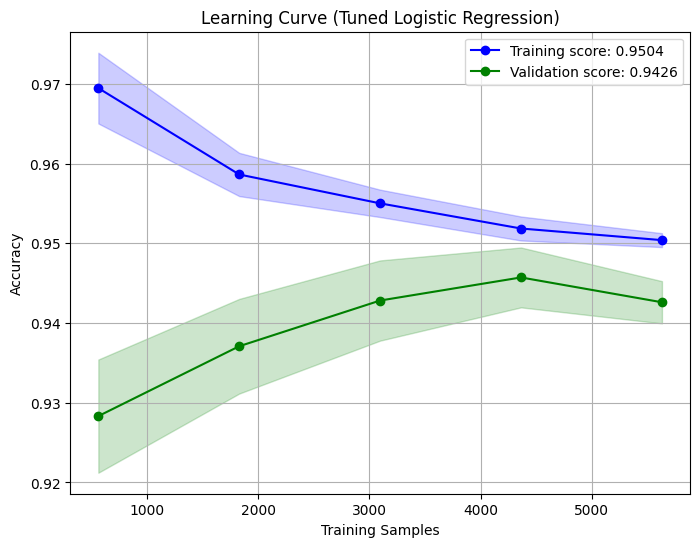

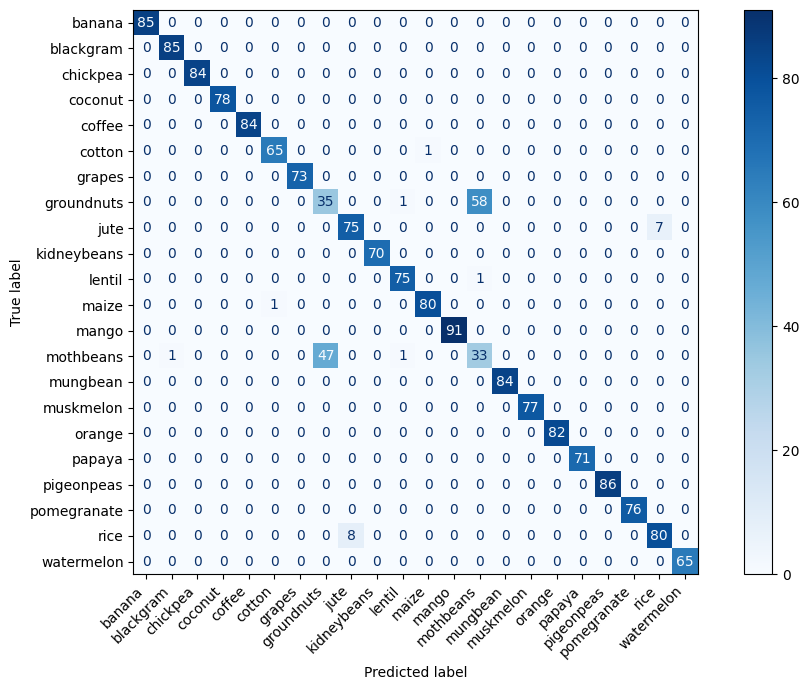

In [138]:
best_logreg = logreg_search.best_estimator_

best_logreg_pred = best_logreg.predict(X_test)

best_logreg_f1 = f1_score(y_test, best_logreg_pred, average="macro")
best_logreg_recall = recall_score(y_test, best_logreg_pred, average="macro")
best_logreg_precision = precision_score(y_test, best_logreg_pred, average="macro")

print(f"F1 Score: {best_logreg_f1:.4f}")
print(f"Recall: {best_logreg_recall:.4f}")
print(f"Precision: {best_logreg_precision:.4f}")

show_learning_curve(best_logreg, "Tuned Logistic Regression", X_train, y_train, cv)
show_confusion_matrix(y_test, best_logreg_pred, display_labels=le.classes_)

In [99]:
rf_clf = Pipeline([
    ("preprocessor", default_preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [10, 20, 50],
    'classifier__max_depth': [5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['log2', 'sqrt']
}

rf_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Hyperparameters:", rf_search.best_params_)
print("Best CV Accuracy:", rf_search.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Hyperparameters: {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 10}
Best CV Accuracy: 0.9379261363636363


F1 Score: 0.9278
Recall: 0.9316
Precision: 0.9284


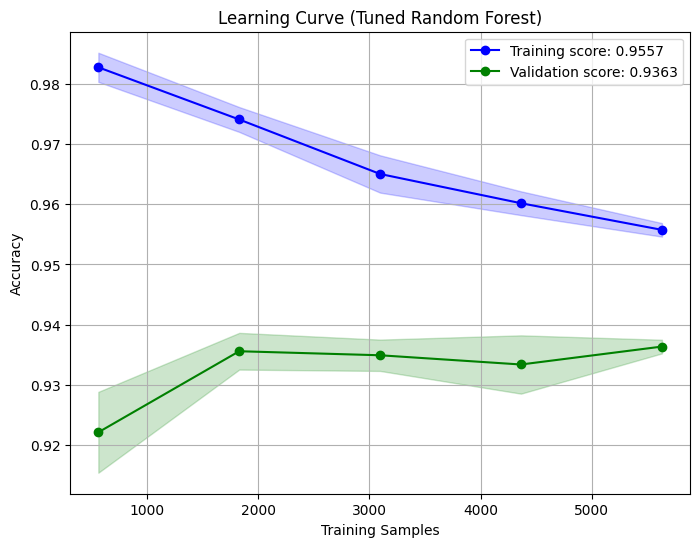

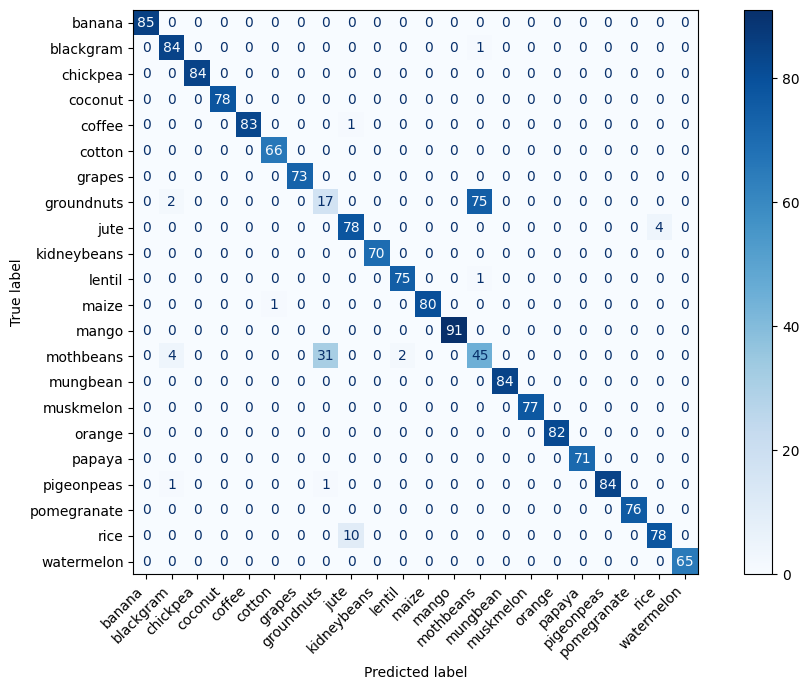

In [139]:
best_rf = rf_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)

best_rf_f1 = f1_score(y_test, best_rf_pred, average="macro")
best_rf_recall = recall_score(y_test, best_rf_pred, average="macro")
best_rf_precision = precision_score(y_test, best_rf_pred, average="macro")

print(f"F1 Score: {best_rf_f1:.4f}")
print(f"Recall: {best_rf_recall:.4f}")
print(f"Precision: {best_rf_precision:.4f}")

show_learning_curve(best_rf, "Tuned Random Forest", X_train, y_train, cv)
show_confusion_matrix(y_test, best_rf_pred, display_labels=le.classes_)

Best CV Accuracy: 0.9822


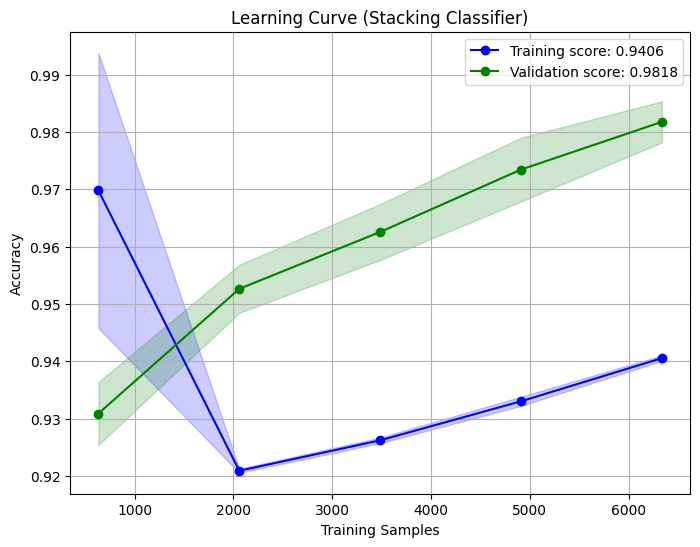

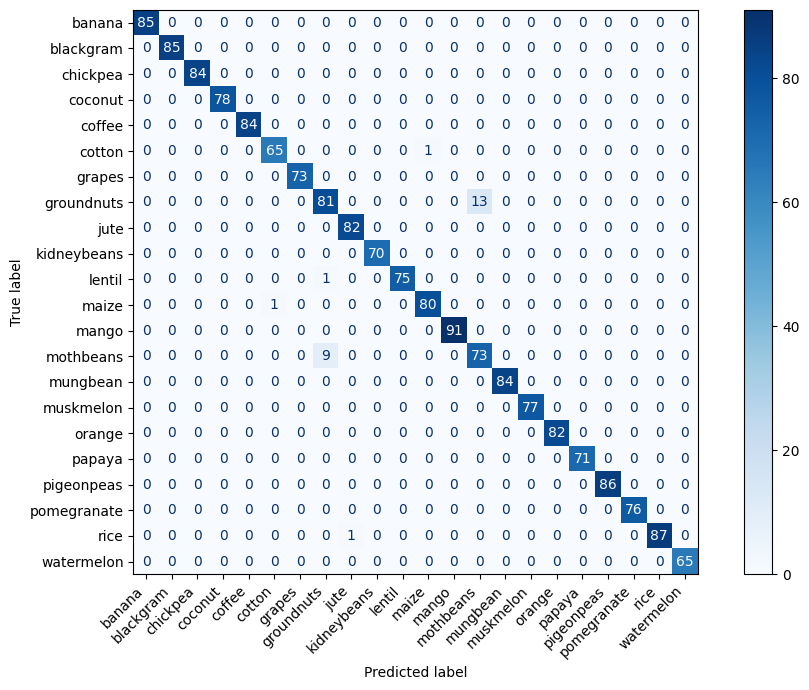

F1 Score: 0.9863
Recall: 0.9864
Precision: 0.9863


In [142]:
rf_lvl0 = Pipeline([
    ('preprocessor', default_preprocessor),
    ('model',  RandomForestClassifier(random_state=42))
])
gnb_lvl0 = Pipeline([
    ('preprocessor', default_preprocessor),
    ('model',  GaussianNB())
])

stack_clf = StackingClassifier(
    estimators=[
        ('rf', rf_lvl0),
        ('gnb', gnb_lvl0),
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000)
)

stack_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

stacked_model, stacked_score = cv_fit_no_search(stack_clf, X_train, y_train, cv=10)
print(f"Best CV Accuracy: {stacked_score:.4f}")

show_learning_curve(stack_clf, "Stacking Classifier", X_train, y_train, stack_cv)

stacked_pred = stacked_model.predict(X_test)
show_confusion_matrix(y_test, stacked_pred, display_labels=le.classes_)

best_stacked_f1 = f1_score(y_test, stacked_pred, average="macro")
best_stacked_recall = recall_score(y_test, stacked_pred, average="macro")
best_stacked_precision = precision_score(y_test, stacked_pred, average="macro")

print(f"F1 Score: {best_stacked_f1:.4f}")
print(f"Recall: {best_stacked_recall:.4f}")
print(f"Precision: {best_stacked_precision:.4f}")

In [117]:
report = classification_report(le.inverse_transform(y_test), le.inverse_transform(stacked_pred), output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
banana,1.000000,1.000000,1.000000,85.000000
blackgram,1.000000,1.000000,1.000000,85.000000
chickpea,1.000000,1.000000,1.000000,84.000000
coconut,1.000000,1.000000,1.000000,78.000000
coffee,1.000000,1.000000,1.000000,84.000000
cotton,0.984848,0.984848,0.984848,66.000000
grapes,1.000000,1.000000,1.000000,73.000000
groundnuts,0.890110,0.861702,0.875676,94.000000
jute,0.987952,1.000000,0.993939,82.000000
kidneybeans,1.000000,1.000000,1.000000,70.000000


In [126]:
with open("stacked_model.pkl", "wb") as f:
    pickle.dump(stacked_model, f)

In [127]:
print("pipeline finished")

pipeline finished
